<a href="https://colab.research.google.com/github/saikrishna5655/ARIA-AI-Voice-Text-Assistant/blob/main/Hospital_Readmission_Part2_Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Hospital Readmission Prediction
## Part 2: Feature Selection & Exploration

Now that our data is clean, we need to identify which features are most useful for predicting readmission within 30 days.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset from Part 1
df = pd.read_csv('/content/diabetes_data_cleaned.csv')

print(f"Cleaned data loaded!")
print(f"Shape: {len(df):,} rows × {len(df.columns)} columns")


Cleaned data loaded!
Shape: 99,493 rows × 45 columns


In [2]:
# Print all column names with their data types
print("All columns in your dataset:")
print("=" * 60)
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    print(f"{i:2}. {col:35} ({dtype})")

All columns in your dataset:
 1. encounter_id                        (int64)
 2. patient_nbr                         (int64)
 3. race                                (object)
 4. gender                              (object)
 5. age                                 (object)
 6. admission_type_id                   (int64)
 7. discharge_disposition_id            (int64)
 8. admission_source_id                 (int64)
 9. time_in_hospital                    (int64)
10. num_lab_procedures                  (int64)
11. num_procedures                      (int64)
12. num_medications                     (int64)
13. number_outpatient                   (int64)
14. number_emergency                    (int64)
15. number_inpatient                    (int64)
16. diag_1                              (object)
17. diag_2                              (object)
18. diag_3                              (object)
19. number_diagnoses                    (int64)
20. metformin                           (object)
21. 

## Understanding Our 45 Columns

Looking at the column list, they naturally fall into 5 groups:

1. **IDs** (columns 1-2): encounter_id, patient_nbr
2. **Demographics** (columns 3-5): race, gender, age
3. **Admission Info** (columns 6-15): how they came in, how long they stayed
4. **Diagnosis Codes** (columns 16-19): what diseases they have
5. **Medications** (columns 20-42): 23 different diabetes medications!
6. **Treatment Info** (columns 43-44): change, diabetesMed
7. **Target** (column 45): readmitted


Check the Medication Columns

In [3]:
# Let's see what values medication columns contain
print("Sample medication column values:")
print(df['metformin'].value_counts())
print("\n")
print(df['insulin'].value_counts())

Sample medication column values:
metformin
No        79972
Steady    17920
Up         1039
Down        562
Name: count, dtype: int64


insulin
No        46496
Steady    29902
Down      12039
Up        11056
Name: count, dtype: int64


Check How Many Patients Are on ANY Diabetes Medication

In [4]:
# List all medication columns
med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
               'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
               'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
               'miglitol', 'troglitazone', 'tolazamide', 'examide',
               'citoglipton', 'insulin', 'glyburide-metformin',
               'glipizide-metformin', 'glimepiride-pioglitazone',
               'metformin-rosiglitazone', 'metformin-pioglitazone']

# Check how many medications each patient is actually taking
for col in med_columns:
    not_no = (df[col] != 'No').sum()
    pct = (not_no / len(df)) * 100
    print(f"{col:35}: {pct:.1f}% of patients taking it")

metformin                          : 19.6% of patients taking it
repaglinide                        : 1.5% of patients taking it
nateglinide                        : 0.7% of patients taking it
chlorpropamide                     : 0.1% of patients taking it
glimepiride                        : 5.1% of patients taking it
acetohexamide                      : 0.0% of patients taking it
glipizide                          : 12.5% of patients taking it
glyburide                          : 10.4% of patients taking it
tolbutamide                        : 0.0% of patients taking it
pioglitazone                       : 7.2% of patients taking it
rosiglitazone                      : 6.3% of patients taking it
acarbose                           : 0.3% of patients taking it
miglitol                           : 0.0% of patients taking it
troglitazone                       : 0.0% of patients taking it
tolazamide                         : 0.0% of patients taking it
examide                            : 

Drop the Near-Zero Medication Columns

In [5]:
# Drop medications taken by less than 1% of patients - they add no value
useless_meds = ['acetohexamide', 'tolbutamide', 'troglitazone', 'tolazamide',
                'examide', 'citoglipton', 'miglitol', 'acarbose',
                'chlorpropamide', 'glipizide-metformin', 'glimepiride-pioglitazone',
                'metformin-rosiglitazone', 'metformin-pioglitazone']

df = df.drop(columns=useless_meds)

print(f"✓ Dropped {len(useless_meds)} near-zero medication columns")
print(f"New shape: {len(df):,} rows × {len(df.columns)} columns")

✓ Dropped 13 near-zero medication columns
New shape: 99,493 rows × 32 columns


Now Simplify Remaining Medications

In [6]:
# Instead of Steady/Up/Down/No, let's simplify:
# 0 = Not taking this medication
# 1 = Taking this medication (any dose)

remaining_meds = ['metformin', 'repaglinide', 'nateglinide', 'glimepiride',
                  'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone',
                  'insulin', 'glyburide-metformin']

for col in remaining_meds:
    df[col] = df[col].apply(lambda x: 0 if x == 'No' else 1)

print("✓ Simplified medication columns to 0/1")
print("\nSample check - insulin values now:")
print(df['insulin'].value_counts())

✓ Simplified medication columns to 0/1

Sample check - insulin values now:
insulin
1    52997
0    46496
Name: count, dtype: int64


Check Your Shape Now

In [7]:
print(f"Current dataset: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nColumns remaining:")
print(df.columns.tolist())

Current dataset: 99,493 rows × 32 columns

Columns remaining:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'readmitted']


**Drop** ID Columns

In [8]:
# Drop ID columns - they are just reference numbers, not medical information
df = df.drop(columns=['encounter_id', 'patient_nbr'])

print(f"✓ Dropped ID columns")
print(f"New shape: {len(df):,} rows × {len(df.columns)} columns")

✓ Dropped ID columns
New shape: 99,493 rows × 30 columns


Look at What You Have Left

In [9]:
# Let's see our final columns clearly grouped
print("REMAINING COLUMNS:")
print("=" * 60)
print("\n📍 Demographics:")
print("  race, gender, age")

print("\n📍 Admission Info:")
print("  admission_type_id, discharge_disposition_id, admission_source_id")

print("\n📍 Clinical (what happened during stay):")
print("  time_in_hospital, num_lab_procedures, num_procedures,")
print("  num_medications, number_diagnoses")

print("\n📍 Patient History (prior visits):")
print("  number_outpatient, number_emergency, number_inpatient")

print("\n📍 Diagnosis Codes:")
print("  diag_1, diag_2, diag_3")

print("\n📍 Medications:")
print("  metformin, repaglinide, nateglinide, glimepiride,")
print("  glipizide, glyburide, pioglitazone, rosiglitazone,")
print("  insulin, glyburide-metformin, change, diabetesMed")

print("\n🎯 Target:")
print("  readmitted")

print(f"\nTotal: {len(df.columns)} columns")

REMAINING COLUMNS:

📍 Demographics:
  race, gender, age

📍 Admission Info:
  admission_type_id, discharge_disposition_id, admission_source_id

📍 Clinical (what happened during stay):
  time_in_hospital, num_lab_procedures, num_procedures,
  num_medications, number_diagnoses

📍 Patient History (prior visits):
  number_outpatient, number_emergency, number_inpatient

📍 Diagnosis Codes:
  diag_1, diag_2, diag_3

📍 Medications:
  metformin, repaglinide, nateglinide, glimepiride,
  glipizide, glyburide, pioglitazone, rosiglitazone,
  insulin, glyburide-metformin, change, diabetesMed

🎯 Target:
  readmitted

Total: 30 columns


Let's Prove It With Data

In [10]:
# Does prior emergency visits actually relate to readmission?
print("Average prior emergency visits by readmission status:")
print(df.groupby('readmitted')['number_emergency'].mean().round(2))

Average prior emergency visits by readmission status:
readmitted
<30    0.36
>30    0.29
NO     0.11
Name: number_emergency, dtype: float64


Check the Same for Inpatient Visits

In [11]:
# Does prior inpatient stays relate to readmission?
print("Average prior inpatient visits by readmission status:")
print(df.groupby('readmitted')['number_inpatient'].mean().round(2))

Average prior inpatient visits by readmission status:
readmitted
<30    1.23
>30    0.84
NO     0.39
Name: number_inpatient, dtype: float64


Compare All Patient History Columns

In [12]:
# Compare all 3 history columns together
history_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']
print("Average prior visits by readmission status:")
print(df.groupby('readmitted')[history_cols].mean().round(2))

Average prior visits by readmission status:
            number_outpatient  number_emergency  number_inpatient
readmitted                                                       
<30                      0.44              0.36              1.23
>30                      0.50              0.29              0.84
NO                       0.28              0.11              0.39


Visualize This

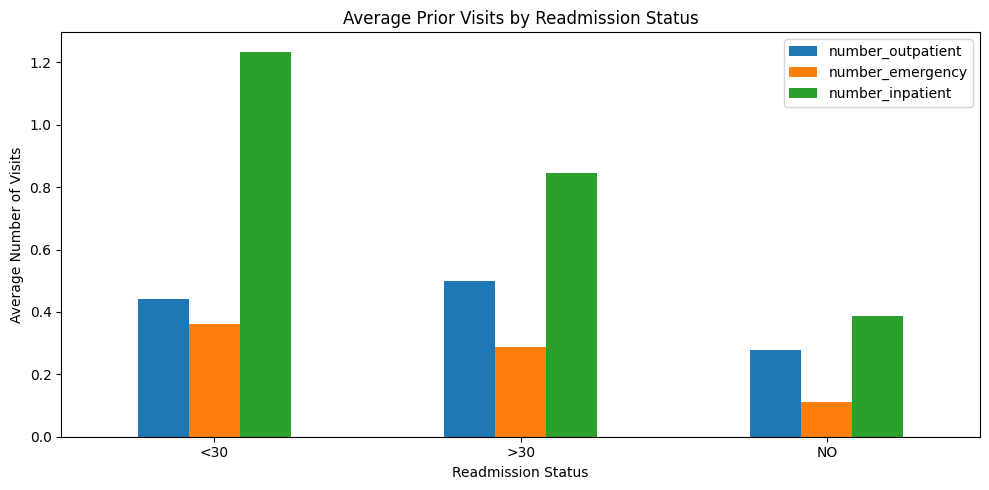

In [13]:
# Visualize patient history vs readmission
history_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']
df.groupby('readmitted')[history_cols].mean().plot(kind='bar', figsize=(10, 5))

plt.title('Average Prior Visits by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Number of Visits')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

 Check Clinical Columns

In [14]:
# Check clinical columns vs readmission
clinical_cols = ['time_in_hospital', 'num_lab_procedures',
                 'num_procedures', 'num_medications', 'number_diagnoses']

print("Average clinical values by readmission status:")
print(df.groupby('readmitted')[clinical_cols].mean().round(2))

Average clinical values by readmission status:
            time_in_hospital  num_lab_procedures  num_procedures  \
readmitted                                                         
<30                     4.77               44.21            1.28   
>30                     4.50               43.79            1.25   
NO                      4.26               42.36            1.41   

            num_medications  number_diagnoses  
readmitted                                     
<30                   16.93              7.71  
>30                   16.27              7.65  
NO                    15.68              7.24  


Clear patterns:

<30 patients stay longest (4.77 days) vs NO (4.26 days)

<30 patients take most medications (16.93) vs NO (15.68)

<30 patients have most diagnoses (7.71) vs NO (7.24)

The surprising part:

num_procedures is actually highest for NO group (1.41)!

That means more procedures = better outcome. Why? Procedures fix problems! A surgery that fixes the issue means patient doesn't come back.

Visualize Clinical Columns

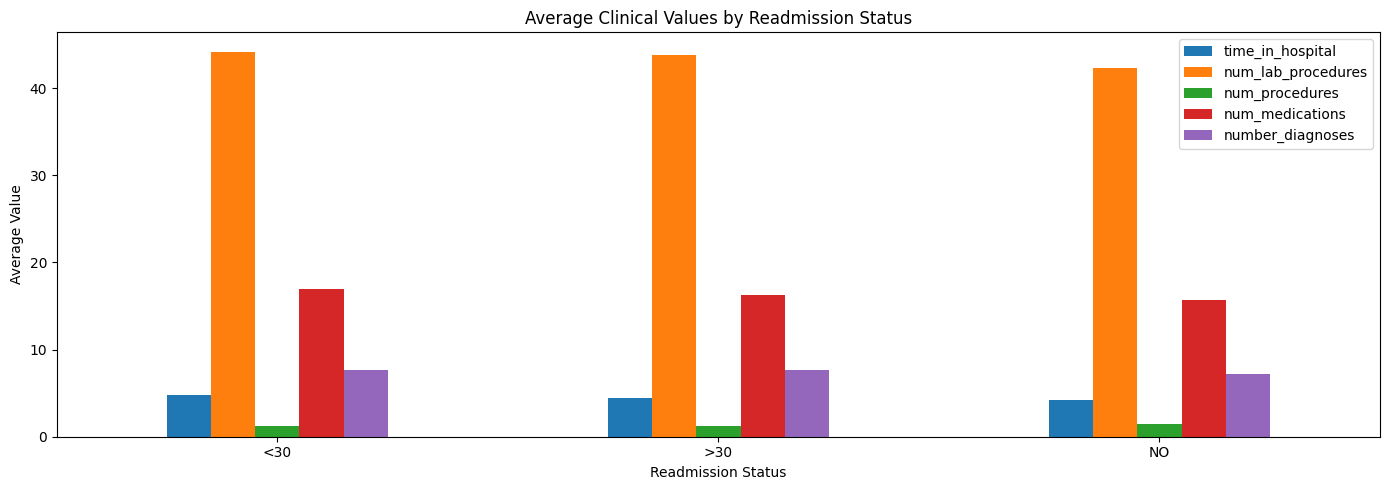

In [15]:
# Visualize clinical columns vs readmission
df.groupby('readmitted')[clinical_cols].mean().plot(kind='bar', figsize=(14, 5))

plt.title('Average Clinical Values by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

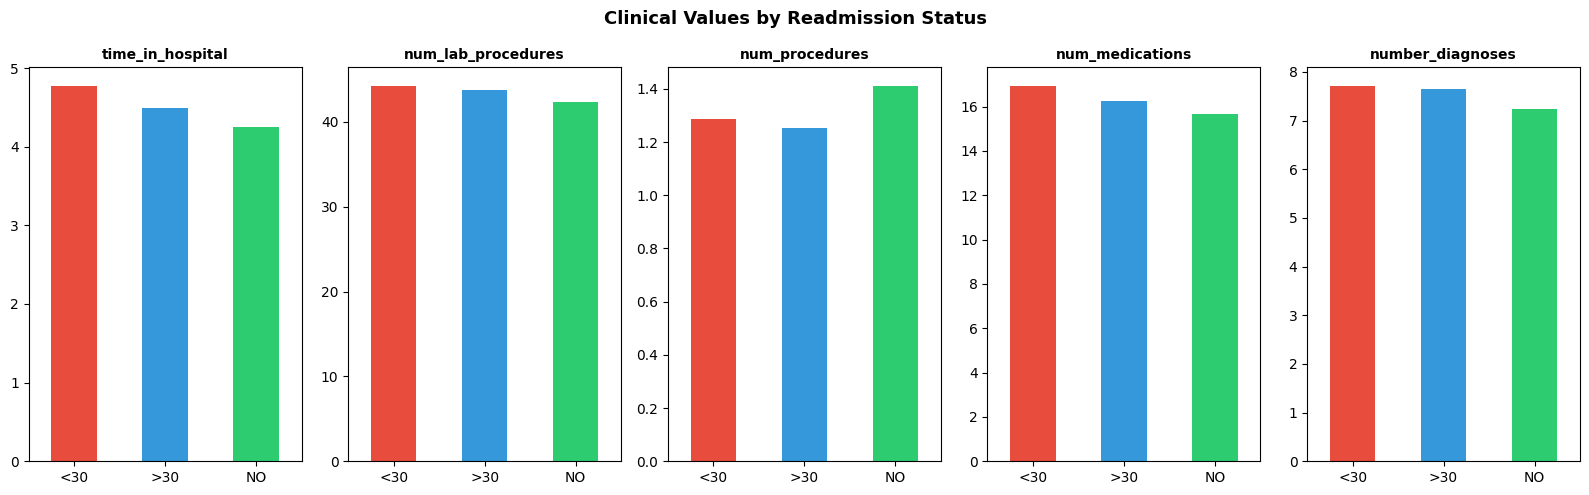

In [16]:
# Plot each clinical column separately so we can actually see the differences
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for idx, col in enumerate(clinical_cols):
    df.groupby('readmitted')[col].mean().plot(kind='bar',
                                               ax=axes[idx],
                                               color=['#e74c3c', '#3498db', '#2ecc71'])
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_xticklabels(['<30', '>30', 'NO'], rotation=0)

plt.suptitle('Clinical Values by Readmission Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##What the charts are telling you:

time_in_hospital → higher for <30 ✅ useful

num_lab_procedures → higher for <30 ✅ useful

num_medications → higher for <30 ✅ useful

number_diagnoses → higher for <30 ✅ useful

num_procedures → NO group is highest ❌ opposite pattern

In simple words:

A patient most likely to be readmitted within 30 days is someone who:

Stayed longer in hospital

Had more lab tests run (doctors were concerned)

Was on more medications (complex condition)

Had more diseases at once

These are all signs of a very sick, complex patient.

Now Let's Create our Target Variable

In [17]:
# Convert readmitted into binary (0 or 1)
# 1 = readmitted within 30 days (HIGH RISK)
# 0 = everything else (not readmitted or readmitted after 30 days)

df['readmit_30'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("New target variable distribution:")
print(df['readmit_30'].value_counts())
print("\nPercentages:")
print((df['readmit_30'].value_counts(normalize=True) * 100).round(2))

New target variable distribution:
readmit_30
0    88324
1    11169
Name: count, dtype: int64

Percentages:
readmit_30
0    88.77
1    11.23
Name: proportion, dtype: float64


Drop the Old Readmitted Column

In [18]:
# Drop the original readmitted column - we don't need it anymore
# We have our new clean binary target: readmit_30
df = df.drop(columns=['readmitted'])

print(f"✓ Dropped original readmitted column")
print(f"Final shape: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nTarget column 'readmit_30' is now:")
print(f"  0 = Not readmitted within 30 days (88.77%)")
print(f"  1 = Readmitted within 30 days (11.23%)")

✓ Dropped original readmitted column
Final shape: 99,493 rows × 30 columns

Target column 'readmit_30' is now:
  0 = Not readmitted within 30 days (88.77%)
  1 = Readmitted within 30 days (11.23%)


In [ ]:
print(df['diag_1'].value_counts().head(10))

diag_1
428    6739
414    6407
786    3938
410    3518
486    3425
427    2712
491    2228
715    2099
682    1996
780    1991
Name: count, dtype: int64


Extract Disease Category from Diagnosis Codes

In [19]:
# Extract first 3 characters to get disease category
# This groups 250.01, 250.13, 250.80 all into "250" (diabetes)

df['diag_1'] = df['diag_1'].astype(str).str[:3]
df['diag_2'] = df['diag_2'].astype(str).str[:3]
df['diag_3'] = df['diag_3'].astype(str).str[:3]

print("diag_1 top values after grouping:")
print(df['diag_1'].value_counts().head(10))

diag_1 top values after grouping:
diag_1
250    8568
428    6739
414    6407
786    3938
410    3518
486    3425
427    2712
491    2228
715    2099
682    1996
Name: count, dtype: int64


In [20]:
print(f"\nUnique values in diag_1: {df['diag_1'].nunique()}")
print(f"Unique values in diag_2: {df['diag_2'].nunique()}")
print(f"Unique values in diag_3: {df['diag_3'].nunique()}")


Unique values in diag_1: 682
Unique values in diag_2: 671
Unique values in diag_3: 696


## 🏥 Handling Diagnosis Codes

ICD-9 diagnosis codes tell us what diseases the patient has. Instead of using
exact codes (250.01, 250.13 etc.), we group them into major disease categories
using the first 3 digits.

However, even after grouping we still have 682 unique categories - too many for
a model to learn from effectively.

**Solution:** Group codes into broader disease families:
- 250 range = Diabetes
- 390-459 range = Heart/Circulatory diseases  
- 460-519 range = Respiratory diseases
- Everything else = Other

This reduces 682 categories into just a few meaningful groups!

Group Diagnosis Codes Into Disease Families

In [21]:
# Function to group ICD-9 codes into disease families
def group_diagnosis(code):
    try:
        code = str(code).strip()
        # Handle special codes starting with V or E
        if code.startswith('V'):
            return 'Other'
        if code.startswith('E'):
            return 'Other'

        # Convert to number for range comparison
        num = float(code)

        if 250 <= num <= 250.99:
            return 'Diabetes'
        elif 390 <= num <= 459:
            return 'Heart'
        elif 460 <= num <= 519:
            return 'Respiratory'
        elif 520 <= num <= 579:
            return 'Digestive'
        elif 800 <= num <= 999:
            return 'Injury'
        else:
            return 'Other'
    except:
        return 'Other'

# Apply to all 3 diagnosis columns
df['diag_1'] = df['diag_1'].apply(group_diagnosis)
df['diag_2'] = df['diag_2'].apply(group_diagnosis)
df['diag_3'] = df['diag_3'].apply(group_diagnosis)

print("✓ Diagnosis codes grouped into disease families")
print("\ndiag_1 distribution:")
print(df['diag_1'].value_counts())

✓ Diagnosis codes grouped into disease families

diag_1 distribution:
diag_1
Other          35249
Heart          29654
Respiratory    10171
Digestive       9036
Diabetes        8568
Injury          6815
Name: count, dtype: int64


Verify the Grouping

In [22]:
# Check unique values now
print(f"Unique values in diag_1: {df['diag_1'].nunique()}")
print(f"Unique values in diag_2: {df['diag_2'].nunique()}")
print(f"Unique values in diag_3: {df['diag_3'].nunique()}")

Unique values in diag_1: 6
Unique values in diag_2: 6
Unique values in diag_3: 6


*Save* our Progress

In [23]:
# Save current progress
df.to_csv('diabetes_data_featured.csv', index=False)

print("✓ Progress saved!")
print(f"Shape: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nWhat we have now:")
print(f"  • Clean data - 0 missing values")
print(f"  • Binary target - readmit_30 (0 or 1)")
print(f"  • Simplified medications - 0/1 values")
print(f"  • Grouped diagnosis codes - 6 disease families")
print(f"\nColumns remaining:")
print(df.columns.tolist())

✓ Progress saved!
Shape: 99,493 rows × 30 columns

What we have now:
  • Clean data - 0 missing values
  • Binary target - readmit_30 (0 or 1)
  • Simplified medications - 0/1 values
  • Grouped diagnosis codes - 6 disease families

Columns remaining:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'readmit_30']


Check Which Columns Are Still Text

In [24]:
# Check which columns are still text (object type)
text_cols = df.select_dtypes(include='object').columns.tolist()
print("Columns still in text format:")
for col in text_cols:
    print(f"  • {col}: {df[col].unique()}")

Columns still in text format:
  • race: ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
  • gender: ['Female' 'Male' 'Unknown/Invalid']
  • age: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
  • diag_1: ['Diabetes' 'Other' 'Heart' 'Respiratory' 'Injury' 'Digestive']
  • diag_2: ['Other' 'Diabetes' 'Heart' 'Respiratory' 'Injury' 'Digestive']
  • diag_3: ['Other' 'Heart' 'Diabetes' 'Respiratory' 'Injury' 'Digestive']
  • change: ['No' 'Ch']
  • diabetesMed: ['No' 'Yes']


##Two Types of Categorical Columns
###Simple Yes/No columns (easy to convert):

change: No/Ch → just 0 and 1

diabetesMed: No/Yes → just 0 and 1

gender: Female/Male → just 0 and 1

###Multiple categories (need more thought):

race: 5 categories

age: 10 age groups

diag_1, diag_2, diag_3: 6 disease families

### Convert Simple Binary Columns

In [25]:
# Convert simple Yes/No columns to 0 and 1
df['change'] = df['change'].apply(lambda x: 1 if x == 'Ch' else 0)
df['diabetesMed'] = df['diabetesMed'].apply(lambda x: 1 if x == 'Yes' else 0)
df['gender'] = df['gender'].apply(lambda x: 1 if x == 'Female' else 0)

print("✓ Converted binary columns")
print(f"\nchange values: {df['change'].unique()}")
print(f"diabetesMed values: {df['diabetesMed'].unique()}")
print(f"gender values: {df['gender'].unique()}")

✓ Converted binary columns

change values: [0 1]
diabetesMed values: [0 1]
gender values: [1 0]


#### Convert Age Groups to Numbers

In [26]:
# Convert age groups to midpoint numbers
age_map = {
    '[0-10)' : 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

df['age'] = df['age'].map(age_map)

print("✓ Age converted to midpoint numbers")
print(f"\nAge values now: {sorted(df['age'].unique())}")
print(f"\nAge distribution:")
print(df['age'].value_counts().sort_index())

✓ Age converted to midpoint numbers

Age values now: [np.int64(5), np.int64(15), np.int64(25), np.int64(35), np.int64(45), np.int64(55), np.int64(65), np.int64(75), np.int64(85), np.int64(95)]

Age distribution:
age
5       160
15      682
25     1611
35     3699
45     9465
55    16895
65    21988
75    25469
85    16800
95     2724
Name: count, dtype: int64


Age 75 has the most patients - 25,469! That makes complete sense for a diabetes dataset. Elderly patients dominate because diabetes complications increase significantly with age.

Now the last remaining text columns - race and diag_1, diag_2, diag_3.

These have multiple categories (not just Yes/No), so we can't just use 0 and 1. We need a different approach.

Think about it this way. If you convert race like:

Caucasian = 1

AfricanAmerican = 2

Hispanic = 3

The model might think Hispanic (3) is 3x more important than Caucasian (1). That's wrong! They're just different categories, not rankings.

Solution: One-Hot Encoding

Instead of one column with numbers 1,2,3... you create separate columns for each category:

text
race_Caucasian,  race_AfricanAmerican,  race_Hispanic

Each column just says YES(1) or NO(0) for that category.

### One-Hot Encode Race and Diagnosis Columns

In [27]:
# One-hot encode categorical columns with multiple categories
cols_to_encode = ['race', 'diag_1', 'diag_2', 'diag_3']

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print("✓ One-hot encoding complete!")
print(f"\nNew shape: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nNew columns added:")
print([col for col in df.columns if any(c in col for c in ['race', 'diag'])])

✓ One-hot encoding complete!

New shape: 99,493 rows × 45 columns

New columns added:
['number_diagnoses', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'diag_1_Digestive', 'diag_1_Heart', 'diag_1_Injury', 'diag_1_Other', 'diag_1_Respiratory', 'diag_2_Digestive', 'diag_2_Heart', 'diag_2_Injury', 'diag_2_Other', 'diag_2_Respiratory', 'diag_3_Digestive', 'diag_3_Heart', 'diag_3_Injury', 'diag_3_Other', 'diag_3_Respiratory']


In [31]:
# Final check of your dataset
print("=" * 60)
print("FEATURE SELECTION COMPLETE!")
print("=" * 60)
print(f"\nFinal shape: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nAny missing values: {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['readmit_30'].value_counts())

FEATURE SELECTION COMPLETE!

Final shape: 99,493 rows × 45 columns

Data types:
int64    45
Name: count, dtype: int64

Any missing values: 0

Target distribution:
readmit_30
0    88324
1    11169
Name: count, dtype: int64


The bool columns (True/False) from one-hot encoding need to be converted to proper 0/1 integers. Some models don't handle bool type well.

In [34]:
# Convert boolean columns to integers (0 and 1)
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

print("✓ Converted bool columns to integers")
print(f"\nData types now:")
print(df.dtypes.value_counts())

✓ Converted bool columns to integers

Data types now:
int64    45
Name: count, dtype: int64


In [32]:
# Save final dataset ready for modeling
df.to_csv('diabetes_ready_for_model.csv', index=False)

print("✓ Final dataset saved as 'diabetes_ready_for_model.csv'")
print(f"\nWhat this dataset contains:")
print(f"  • {len(df):,} patient records")
print(f"  • {len(df.columns) - 1} features (input)")
print(f"  • 1 target column (readmit_30)")
print(f"  • 0 missing values")
print(f"  • All numbers - ready for machine learning!")

✓ Final dataset saved as 'diabetes_ready_for_model.csv'

What this dataset contains:
  • 99,493 patient records
  • 44 features (input)
  • 1 target column (readmit_30)
  • 0 missing values
  • All numbers - ready for machine learning!


## ✅ Part 2 Complete: Feature Selection & Engineering

### What We Started With:
- 45 columns (mix of text, numbers, codes)
- 23 medication columns (mostly empty)
- Age as text ranges [0-10), [10-20)...
- Diagnosis codes with 682 unique values
- ID columns with no predictive value

### What We Did:
1. **Dropped** near-zero medication columns (13 columns removed)
2. **Simplified** remaining medications to 0/1 (taking or not)
3. **Dropped** ID columns (encounter_id, patient_nbr)
4. **Discovered** patient history is strongest predictor (number_inpatient!)
5. **Grouped** 682 diagnosis codes into 6 disease families
6. **Converted** age ranges to midpoint numbers
7. **Encoded** binary columns (gender, change, diabetesMed)
8. **One-hot encoded** race and diagnosis categories

### What We Have Now:
- 99,493 patient records
- 44 clean numeric features
- 1 binary target (readmit_30)
- 0 missing values
- All integers - ready for machine learning!

### Key Insight Discovered:
**number_inpatient is the strongest predictor** - patients with
more prior hospital stays are 3x more likely to be readmitted within 30 days.